In [8]:
import pandas as pd
# Load CSV file, not Excel file
df = pd.read_csv("/content/online_retail_II.csv")
# Quick look
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12.0,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12.0,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12.0,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48.0,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24.0,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 212296 entries, 0 to 212295
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      212296 non-null  object 
 1   StockCode    212296 non-null  object 
 2   Description  210512 non-null  object 
 3   Quantity     212295 non-null  float64
 4   InvoiceDate  212295 non-null  object 
 5   Price        212295 non-null  float64
 6   Customer ID  164578 non-null  float64
 7   Country      212295 non-null  object 
dtypes: float64(3), object(5)
memory usage: 13.0+ MB


In [11]:
# Remove rows where Invoice is missing
df = df[df['Invoice'].notna()]

In [12]:
# Remove canceled invoices
df = df[~df['Invoice'].astype(str).str.startswith('C')]

In [13]:
df = df[df['Customer ID'].notna()]

In [15]:
#Negative or zero values are not meaningful for sales analysis.

df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]

In [16]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [17]:
df.isnull().sum()
df.shape

(160101, 8)

In [21]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')
df['InvoiceDate'].dtype

dtype('<M8[ns]')

In [22]:
df[['InvoiceDate']].head()


,InvoiceDate
0,2009-12-01 07:45:00
1,2009-12-01 07:45:00
2,2009-12-01 07:45:00
3,2009-12-01 07:45:00
4,2009-12-01 07:45:00


In [24]:
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

df['TotalAmount'] = df['Quantity'] * df['Price']


In [25]:
df['TotalAmount'].describe()


,TotalAmount
count,160101.000000
mean,22.324157
std,73.717849
min,0.001000
25%,5.040000
50%,12.500000
75%,19.800000
max,10953.500000


In [26]:
df[['Quantity', 'Price', 'TotalAmount']].head()


,Quantity,Price,TotalAmount
0,12.0,6.95,83.4
1,12.0,6.75,81.0
2,12.0,6.75,81.0
3,48.0,2.10,100.8
4,24.0,1.25,30.0


In [28]:
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
reference_date

Timestamp('2010-05-27 13:23:00')

In [30]:
rfm = (
    df.groupby('Customer ID')
    .agg({
        'InvoiceDate': lambda x: (reference_date - x.max()).days,  # Recency
        'Invoice': 'nunique',                                      # Frequency
        'TotalAmount': 'sum'                                       # Monetary
    })
    .reset_index()
)

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']
rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,86,10,230.55
1,12349.0,9,2,1268.52
2,12355.0,6,1,488.21
3,12358.0,170,1,1429.83
4,12359.0,65,4,1522.23


In [31]:
# Recency score (reverse: lower days = higher score)
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1])

# Frequency score
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])

# Monetary score
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5])

In [32]:
rfm['RFM_Score'] = (
    rfm['R_Score'].astype(str) +
    rfm['F_Score'].astype(str) +
    rfm['M_Score'].astype(str)
)

In [34]:
rfm[['CustomerID', 'Recency', 'Frequency', 'Monetary',
     'R_Score', 'F_Score', 'M_Score', 'RFM_Score']].head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,12346.0,86,10,230.55,2,5,2,252
1,12349.0,9,2,1268.52,5,3,4,534
2,12355.0,6,1,488.21,5,1,3,513
3,12358.0,170,1,1429.83,1,1,5,115
4,12359.0,65,4,1522.23,2,4,5,245


In [35]:
rfm['RFM_Score_Sum'] = (
    rfm['R_Score'].astype(int) +
    rfm['F_Score'].astype(int) +
    rfm['M_Score'].astype(int)
)

In [37]:
def rfm_segment(row):
    if row['R_Score'] >= 4 and row['F_Score'] >= 4:
        return 'Champions'
    elif row['R_Score'] >= 3 and row['F_Score'] >= 3:
        return 'Loyal Customers'
    elif row['R_Score'] >= 4 and row['F_Score'] >= 2:
        return 'Potential Loyalists'
    elif row['R_Score'] == 5 and row['F_Score'] == 1:
        return 'Recent Customers'
    elif row['R_Score'] <= 2 and row['F_Score'] >= 4:
        return 'Cannot Lose Them'
    elif row['R_Score'] <= 2 and row['F_Score'] >= 3:
        return 'At Risk'
    elif row['R_Score'] == 1 and row['F_Score'] == 1:
        return 'Hibernating'
    else:
        return 'Lost'

rfm['Segment'] = rfm.apply(rfm_segment, axis=1)

rfm[['CustomerID', 'Recency', 'Frequency', 'Monetary',
     'R_Score', 'F_Score', 'M_Score', 'RFM_Score', 'Segment']].head()


,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
0,12346.0,86,10,230.55,2,5,2,252,Cannot Lose Them
1,12349.0,9,2,1268.52,5,3,4,534,Loyal Customers
2,12355.0,6,1,488.21,5,1,3,513,Recent Customers
3,12358.0,170,1,1429.83,1,1,5,115,Hibernating
4,12359.0,65,4,1522.23,2,4,5,245,Cannot Lose Them


In [38]:
rfm['Segment'].value_counts()


,count
Segment,
Lost,710
Champions,630
Loyal Customers,554
Cannot Lose Them,212
At Risk,206
Hibernating,183
Potential Loyalists,120
Recent Customers,56


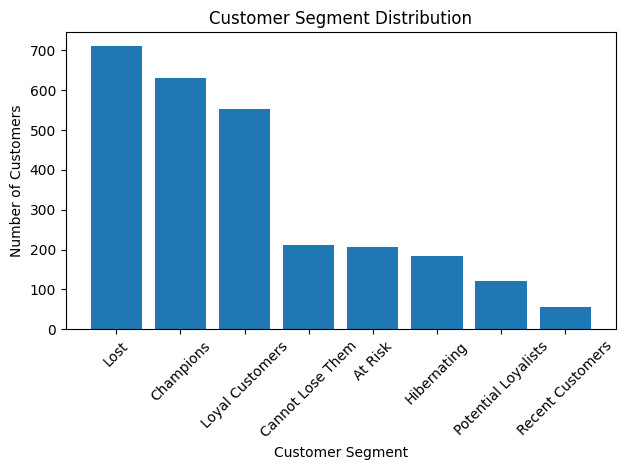

In [39]:
import matplotlib.pyplot as plt

# Count customers in each segment
segment_counts = rfm['Segment'].value_counts()

# Plot bar chart
plt.figure()
plt.bar(segment_counts.index, segment_counts.values)
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.title('Customer Segment Distribution')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [42]:
rfm.to_csv("customer_segmentation_rfm.csv", index=False)
rfm.to_csv("/content/customer_segmentation_rfm.csv", index=False)
pd.read_csv("customer_segmentation_rfm.csv").head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Score_Sum,Segment
0,12346.0,86,10,230.55,2,5,2,252,9,Cannot Lose Them
1,12349.0,9,2,1268.52,5,3,4,534,12,Loyal Customers
2,12355.0,6,1,488.21,5,1,3,513,9,Recent Customers
3,12358.0,170,1,1429.83,1,1,5,115,7,Hibernating
4,12359.0,65,4,1522.23,2,4,5,245,11,Cannot Lose Them


In [44]:
rfm_final = rfm[
    ['CustomerID', 'Recency', 'Frequency', 'Monetary',
     'R_Score', 'F_Score', 'M_Score', 'RFM_Score', 'Segment']
]
rfm_final.to_csv('customer_rfm_segmentation.csv', index=False)

from google.colab import files
files.download('customer_rfm_segmentation.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>